In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.duplicated().sum()

165

In [8]:
df = df.drop_duplicates(keep='first')
df.shape

(32416, 12)

In [9]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

y.value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [10]:
cat_features = X.select_dtypes(include='object').columns.tolist()
X[cat_features] = X[cat_features].astype('category')
cat_features = X.select_dtypes(include='category').columns.tolist()
cat_features

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

model = CatBoostClassifier(
    class_weights=[1, 3],
    loss_function='Logloss',
    iterations=500,
    learning_rate=0.1,
    depth=8,
    eval_metric='Accuracy',
    l2_leaf_reg=1,
    random_seed=42
)

model.fit(train_pool, eval_set=test_pool, use_best_model=True)

0:	learn: 0.8286205	test: 0.8287554	best: 0.8287554 (0)	total: 107ms	remaining: 53.6s
1:	learn: 0.8310887	test: 0.8286481	best: 0.8287554 (0)	total: 156ms	remaining: 38.8s
2:	learn: 0.8392982	test: 0.8368026	best: 0.8368026 (2)	total: 199ms	remaining: 32.9s
3:	learn: 0.8410152	test: 0.8419528	best: 0.8419528 (3)	total: 252ms	remaining: 31.2s
4:	learn: 0.8425712	test: 0.8413090	best: 0.8419528 (3)	total: 281ms	remaining: 27.8s
5:	learn: 0.8453882	test: 0.8444206	best: 0.8444206 (5)	total: 340ms	remaining: 28s
6:	learn: 0.8464077	test: 0.8453863	best: 0.8453863 (6)	total: 397ms	remaining: 27.9s
7:	learn: 0.8551537	test: 0.8552575	best: 0.8552575 (7)	total: 442ms	remaining: 27.2s
8:	learn: 0.8571659	test: 0.8569742	best: 0.8569742 (8)	total: 486ms	remaining: 26.5s
9:	learn: 0.8569512	test: 0.8560086	best: 0.8569742 (8)	total: 531ms	remaining: 26s
10:	learn: 0.8577829	test: 0.8559013	best: 0.8569742 (8)	total: 583ms	remaining: 25.9s
11:	learn: 0.8588292	test: 0.8549356	best: 0.8569742 (8)	

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.9359962985811228
Precision (weighted): 0.9354339350080672
Recall (weighted): 0.9359962985811228
F1 Score (weighted): 0.9338511312237374


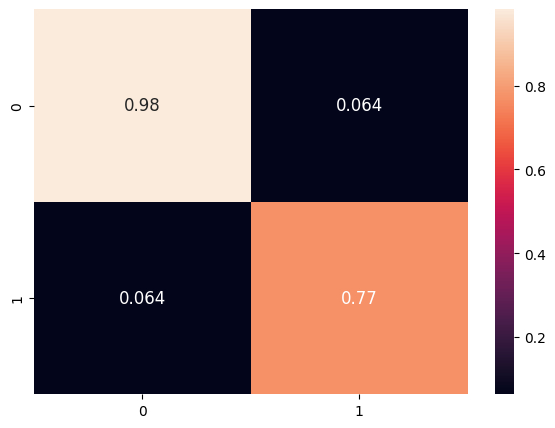

In [14]:
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sb.heatmap(cfm / np.sum(cfm, axis=1), annot=True, fmt=".2", annot_kws={"size": 12})
plt.show()

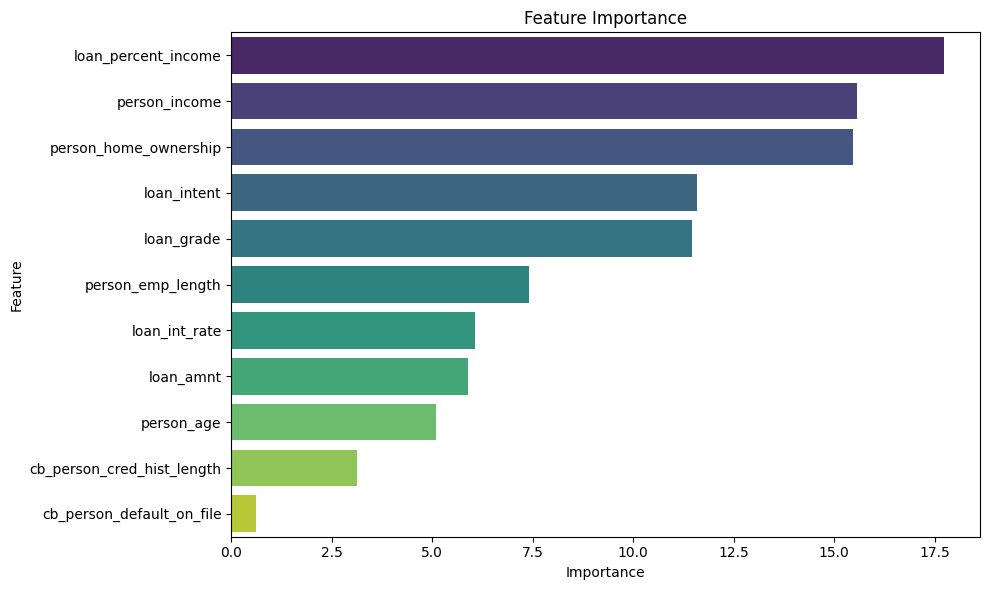

In [15]:
importances = model.get_feature_importance()
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [16]:
model.save_model("catboost_model.cbm")

In [17]:
X_new = pd.DataFrame([{
    'person_age': 50,
    'person_income': 5000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 12.7,
    'loan_intent': 'PERSONAL',
    'loan_grade': 'B',
    'loan_amnt': 100000,
    'loan_int_rate': 12.1,
    'loan_percent_income': 0.53,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 5
}])

In [18]:
trained_model = CatBoostClassifier()
trained_model.load_model("catboost_model.cbm")
y_pred = trained_model.predict(X_new)

if y_pred[0] == 1:
    print('loan can be approved')
else:
    print('loan is rejected, there is a credit risk')

loan can be approved
